In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Explore dummy data

In [8]:
# explore the dummy_data
import pandas as pd
import torch
artifact_path = '../data/unsw_nb15/NF-UNSW-NB15-v3_input_to_bert.pt'
dummy_data =torch.load(artifact_path)
print("Available splits: ",dummy_data.keys() )

cont_seqs, proto_seqs, port_seqs, attention_mask = dummy_data['train']
print(f'dim of cont_seqs should be: nr_of_seqs, seq_len, 13: {cont_seqs.shape} ')
print(f'dim of proto_seqs should be: nr_of_seqs, seq_len, 1: {proto_seqs.shape} ')
print(f'dim of port_seqs should be: nr_of_seqs, seq_len, 1: {port_seqs.shape} ')
print(f'dim of attention_mask should be: nr_of_seqs, seq_len, 15: {port_seqs.shape} ')

print(attention_mask.unique())
print(port_seqs.max())

Available splits:  dict_keys(['train', 'eval', 'test'])
dim of cont_seqs should be: nr_of_seqs, seq_len, 13: torch.Size([6, 34, 13]) 
dim of proto_seqs should be: nr_of_seqs, seq_len, 1: torch.Size([6, 34]) 
dim of port_seqs should be: nr_of_seqs, seq_len, 1: torch.Size([6, 34]) 
dim of attention_mask should be: nr_of_seqs, seq_len, 15: torch.Size([6, 34]) 
tensor([False,  True])
tensor(65536)


In [3]:
import pandas as pd
data = pd.read_csv('../data/unsw_nb15/NF-UNSW-NB15-v3_raw.csv')
data.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,...,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1424242193040,1424242193043,59.166.0.2,4894,149.171.126.3,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
1,1424242192744,1424242193079,59.166.0.4,52671,149.171.126.6,31992,6,11.0,4704,28,...,0,91,12,19,0,90,12,19,0,Benign
2,1424242190649,1424242193109,59.166.0.0,47290,149.171.126.9,6881,6,37.0,13662,238,...,0,1843,10,119,0,1843,5,88,0,Benign
3,1424242193145,1424242193146,59.166.0.8,43310,149.171.126.7,53,17,5.0,146,2,...,0,0,0,0,0,0,0,0,0,Benign
4,1424242193239,1424242193241,59.166.0.1,45870,149.171.126.1,53,17,5.0,130,2,...,0,0,0,0,0,0,0,0,0,Benign


In [4]:
print(data.columns)

Index(['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR',
       'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO',
       'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS',
       'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS',
       'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT',
       'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
       'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES',
       'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS',
       'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS',
       'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
       'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES',
       'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES',
       'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT',
       'ICMP_TYPE', 'ICMP_IPV4_TYPE', 'DNS_QUERY_ID', 'DNS_QUERY_TYPE',
       'DNS_TTL_ANSWER', 'FTP_COMMAN

In [8]:
flows_per_ip = data.groupby('IPV4_SRC_ADDR').size()
print(flows_per_ip.describe(percentiles=[0.25,0.5,0.75,0.9]))

count        40.000000
mean      59135.600000
std       94856.796931
min           1.000000
25%         352.250000
50%         653.500000
75%       79923.250000
90%      223674.600000
max      225316.000000
dtype: float64


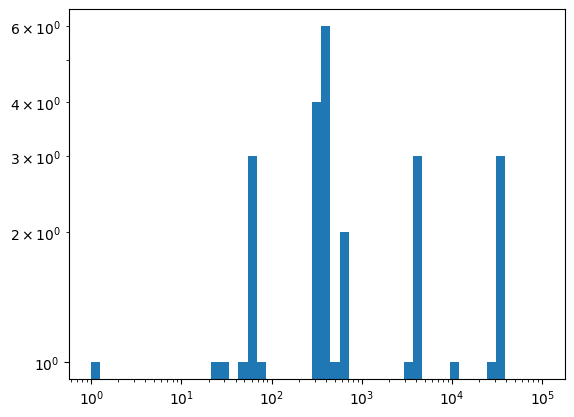

In [13]:
plt.hist(flows_per_ip, bins=np.logspace(0,5,50))
plt.xscale('log')
plt.yscale('log')
plt.show()
